In [ ]:
import numpy as np
import pandas as pd
from copy import deepcopy
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
label_index = {"dry": 0, "normal": 1, "oily": 2}
index_label = {0: "dry", 1: "normal", 2: "oily"}

In [5]:
def create_df(base):
    dd = {"images": [], "labels": []}
    for i in os.listdir(base):
        label = os.path.join(base, i)
        for j in os.listdir(label):
            img = os.path.join(label, j)
            dd["images"].append(img)
            dd["labels"].append(label_index[i])
    return pd.DataFrame(dd)

# Creating dataset

In [6]:
DATASET_PATH = "Oily-Dry-Skin-Types"

train_df = create_df(os.path.join(DATASET_PATH, "train"))
val_df = create_df(os.path.join(DATASET_PATH, "valid"))
test_df = create_df(os.path.join(DATASET_PATH, "test"))

In [7]:
train_df = pd.concat([train_df, val_df, test_df])

In [8]:
print(train_df.head())

                                              images  labels
0  Oily-Dry-Skin-Types\train\dry\dry_003e3600c061...       0
1  Oily-Dry-Skin-Types\train\dry\dry_003e3600c061...       0
2  Oily-Dry-Skin-Types\train\dry\dry_003e3600c061...       0
3  Oily-Dry-Skin-Types\train\dry\dry_00f1189752d6...       0
4  Oily-Dry-Skin-Types\train\dry\dry_00f1189752d6...       0


# Defining training parameters

In [9]:
EPOCHS = 20
LR = 0.1
STEP = 15
GAMMA = 0.1
BATCH = 32
OUT_CLASSES = 3
IMG_SIZE = 224

In [10]:
class CloudDS(Dataset):
    def __init__(self, data, transform):
        super(CloudDS, self).__init__()
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, x):
        img, label = self.data.iloc[x, 0], self.data.iloc[x, 1]
        img = Image.open(img).convert("RGB")
        img = self.transform(np.array(img))
        
        return img, label

In [11]:
train_transform = transforms.Compose([transforms.ToPILImage(),
                               transforms.ToTensor(),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                transforms.RandomVerticalFlip(0.6),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])])

transform = transforms.Compose([transforms.ToPILImage(),
                               transforms.ToTensor(),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])])

In [12]:
train, testing = train_test_split(train_df, random_state=42, test_size=0.2)
val, test = train_test_split(testing, random_state=42, test_size=0.5)

In [ ]:
train_ds = CloudDS(train, train_transform)
val_ds = CloudDS(val, transform)

In [14]:
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

# Downloading ResNet50

In [15]:
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = resnet.fc.in_features
resnet.fc.in_features = nn.Linear(num_ftrs, OUT_CLASSES)

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Training tools

In [18]:
model = deepcopy(resnet)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)

# Training

In [19]:
best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, EPOCHS+1):
    model.train()
    
    diff = 0
    total = 0
    acc = 0
    
    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()
            
        out = model(data)
        loss = criterion(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)
        loss.backward()
        optimizer.step()
        
    train_loss += [diff/total]
    train_acc += [acc/total]
    
    model.eval()
    
    diff = 0
    total = 0
    acc = 0
    
    with torch.no_grad():
        for data, target in val_dl:
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()
                
            out = model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)
            
    val_loss += [diff/total]
    val_acc += [acc/total]
    
    if val_acc[-1] > best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(model)
        
    scheduler.step()
    
    print("Epochs {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1],
                                                                    train_acc[-1], val_loss[-1],
                                                                    val_acc[-1]))

Epochs 1 train loss 0.045464116753400764 acc 0.46092820309401034 val loss 0.0414624051442222 acc 0.4095238095238095
Epochs 2 train loss 0.023076928794407647 acc 0.6866322887742959 val loss 0.03097117893279545 acc 0.5714285714285714
Epochs 3 train loss 0.014998831271605093 acc 0.8088060293534312 val loss 0.03527148242980715 acc 0.5650793650793651
Epochs 4 train loss 0.00946223530408552 acc 0.8817929393097977 val loss 0.029666066926623148 acc 0.6666666666666666
Epochs 5 train loss 0.0077555985372840105 acc 0.9083696945656485 val loss 0.03095876205535162 acc 0.6825396825396826
Epochs 6 train loss 0.005122628535089726 acc 0.9520031733439112 val loss 0.03233575783078633 acc 0.7333333333333333
Epochs 7 train loss 0.0035779634945002966 acc 0.9603332011106703 val loss 0.02311266807336656 acc 0.7873015873015873
Epochs 8 train loss 0.0026287766051940834 acc 0.9738199127330425 val loss 0.026890721822541857 acc 0.765079365079365
Epochs 9 train loss 0.002436722535492231 acc 0.974613248710829 val lo

# Model's performance log

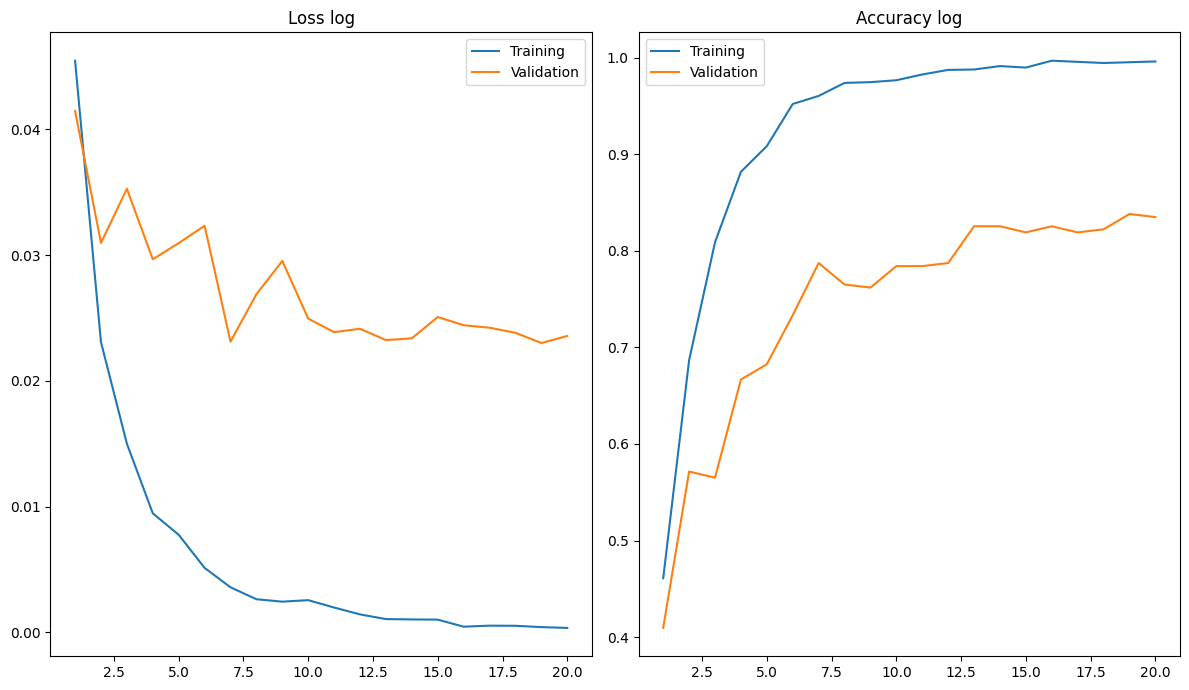

In [20]:
epochs = list(range(1, EPOCHS+1))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 7))
axes[0].plot(epochs, train_loss)
axes[0].plot(epochs, val_loss)
axes[0].legend(["Training", "Validation"])
axes[0].set_title("Loss log")

axes[1].plot(epochs, train_acc)
axes[1].plot(epochs, val_acc)
axes[1].legend(["Training", "Validation"])
axes[1].set_title("Accuracy log")

plt.tight_layout()
plt.show()

In [21]:
def predict(x):
    img = Image.open(x).convert("RGB")
    img = transform(np.array(img))
    img = img.view(1, 3, 224, 224)
    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            img = img.cuda()
        
        out = best_model(img)
        
        return out.argmax(1).item()

In [22]:
pred = []
truth = []

for i in range(test.shape[0]):
    pred += [predict(test.iloc[i, 0])]
    truth += [test.iloc[i, 1]]

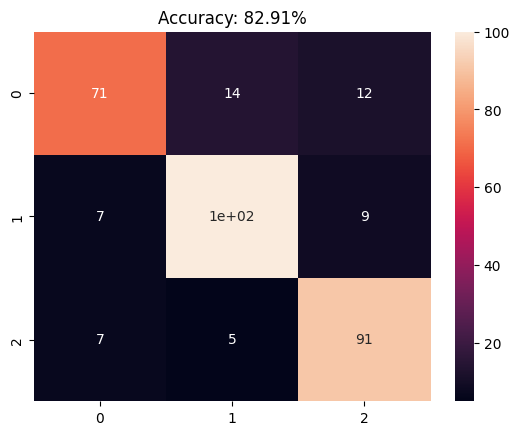

In [23]:
score = accuracy_score(truth, pred)
report = classification_report(truth, pred)
cm = confusion_matrix(truth, pred)
sns.heatmap(cm, annot=True)
plt.title("Accuracy: {}%".format(round(score*100, 2)))
plt.show()

In [24]:
print(report)

              precision    recall  f1-score   support

           0       0.84      0.73      0.78        97
           1       0.84      0.86      0.85       116
           2       0.81      0.88      0.85       103

    accuracy                           0.83       316
   macro avg       0.83      0.83      0.83       316
weighted avg       0.83      0.83      0.83       316



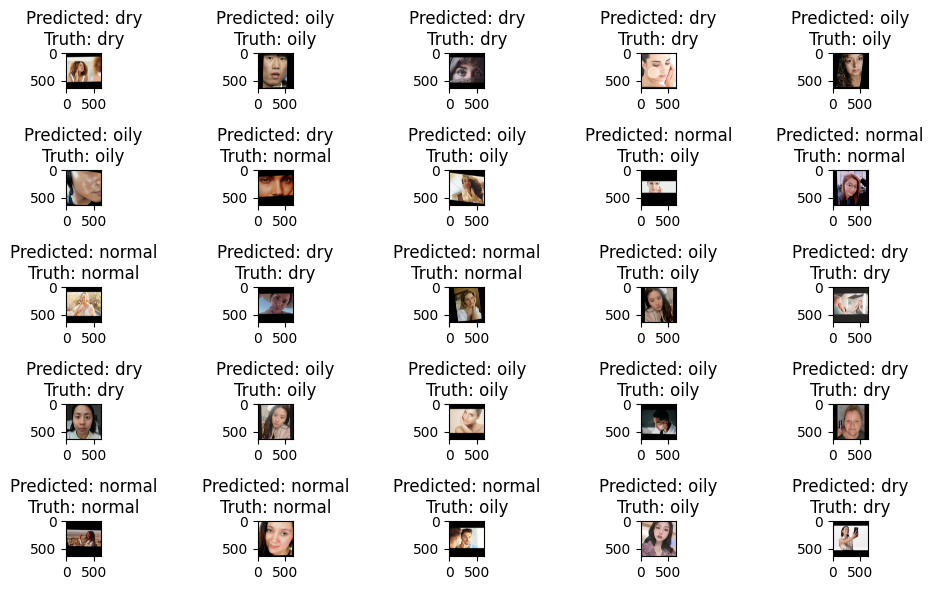

In [25]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 6))
index = 0
for i in range(5):
    for j in range(5):
        img = test.iloc[index, 0]
        img = Image.open(img).convert("RGB")
        axes[i][j].imshow(img)
        axes[i][j].set_title("Predicted: {}\nTruth: {}".format(index_label[pred[index]], index_label[truth[index]]))
        index += 1
        
plt.tight_layout()
plt.show()